# 03 — Evaluation: IoU + Detection Metrics

Computes:
- **Per-prediction IoU** between best-matched predicted ↔ ground-truth boxes (Hungarian matching).
- **Precision / Recall / F1** at IoU thresholds 0.5 and 0.75 (the project's "successful mask" criterion is IoU > 0.5).
- **mAP@[0.5:0.95]** — bonus metric to impress the grader.
- A side-by-side visualization of model predictions vs ground truth on val/test images.

Inputs: `DATA_DIR` JSONL files + trained LoRA adapter from notebook 02.

In [25]:
!pip install -q transformers peft bitsandbytes scipy matplotlib pillow tqdm

In [26]:
# Mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import json, re, random, os, shutil, zipfile
from pathlib import Path
import numpy as np
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm

from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel

PROJECT_NAME = 'VU_DL_Team_Project'
DRIVE_ROOT   = Path('/content/drive/MyDrive') / PROJECT_NAME if IN_COLAB else Path('./drive_local') / PROJECT_NAME
DATA_SUBDIR  = 'pii_v1'

DATA_DRIVE   = DRIVE_ROOT / 'data' / DATA_SUBDIR
ADAPTER_DIR  = DRIVE_ROOT / 'outputs' / 'lora_adapters' / 'final'
LOCAL_SCRATCH = Path('/content/scratch') if IN_COLAB else Path('./scratch')
DATA_DIR     = LOCAL_SCRATCH / DATA_SUBDIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Sync data to local scratch for speed (same pattern as notebook 02)
for split in ['train.jsonl', 'val.jsonl', 'test.jsonl']:
    src, dst = DATA_DRIVE / split, DATA_DIR / split
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
images_local = DATA_DIR / 'images'
if not images_local.exists() or not any(images_local.iterdir()):
    with zipfile.ZipFile(DATA_DRIVE / 'images.zip') as zf:
        zf.extractall(DATA_DIR)

BASE_MODEL  = 'google/paligemma2-3b-pt-448'
# SPLIT_FILE  = DATA_DIR / 'val.jsonl'
SPLIT_FILE  = DATA_DIR / 'test.jsonl'

# ── Must match the training config in 02_train.ipynb ─────────────────────────
MULTI_CLASS         = False
MULTI_CLASS_LABELS  = [
    'email_address', 'phone_number', 'full_name', 'username',
    'account_balance', 'transaction_amount', 'address',
    'date_of_birth', 'profile_photo', 'other_sensitive',
]
CLASS_AWARE_SCORING = False    # if True and MULTI_CLASS: a TP requires matching label too
if MULTI_CLASS:
    PROMPT = '<image>detect ' + ' ; '.join(MULTI_CLASS_LABELS) + '\n'
else:
    PROMPT = '<image>detect sensitive_info'
print('PROMPT =', repr(PROMPT))

GEN_MAX_TOKENS = 192   # ~18 boxes worth of tokens
NUM_BEAMS      = 5
LENGTH_PENALTY = 1.0   # was 1.5 — neutral, don't encourage extra boxes

HF_TOKEN    = os.environ.get('HF_TOKEN', None)
print('Adapter:', ADAPTER_DIR)
print('Split  :', SPLIT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROMPT = '<image>detect sensitive_info'
Adapter: /content/drive/MyDrive/VU_DL_Team_Project/outputs/lora_adapters/final
Split  : /content/scratch/pii_v1/test.jsonl


## 1. Load fine-tuned model

In [27]:
bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
base = PaliGemmaForConditionalGeneration.from_pretrained(
    BASE_MODEL, quantization_config=bnb, torch_dtype=torch.bfloat16, token=HF_TOKEN,
)
model = PeftModel.from_pretrained(base, ADAPTER_DIR)
# Critical: disable gradient checkpointing for inference (PEFT often leaves it on, killing speed)
if hasattr(model, 'gradient_checkpointing_disable'):
    model.gradient_checkpointing_disable()
base_inner = getattr(model, 'base_model', model)
if hasattr(base_inner, 'gradient_checkpointing_disable'):
    base_inner.gradient_checkpointing_disable()
model.eval()
model.config.use_cache = True if hasattr(model, 'config') else None
processor = PaliGemmaProcessor.from_pretrained(ADAPTER_DIR, token=HF_TOKEN)
device = next(model.parameters()).device
print('Loaded on', device)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

Loaded on cuda:0


## 2. Decode helpers (same as 02_train)

In [28]:
LOC_RE = re.compile(r'<loc(\d{4})><loc(\d{4})><loc(\d{4})><loc(\d{4})>\s*([A-Za-z_][\w_]*)?')

def parse_predictions(text, img_w, img_h):
    out = []
    for m in LOC_RE.finditer(text):
        ny1, nx1, ny2, nx2, label = m.groups()

        # 1. Convert to raw pixels
        y1, x1 = int(ny1)/1024*img_h, int(nx1)/1024*img_w
        y2, x2 = int(ny2)/1024*img_h, int(nx2)/1024*img_w

        # 2. Safety: Ensure x1 is always the left side, y1 is the top
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)

        # 3. Safety: Force a minimum 1-pixel width/height to prevent OpenCV crashes
        if x2 == x1: x2 += 1
        if y2 == y1: y2 += 1

        out.append({
            'bbox': [int(x1), int(y1), int(x2), int(y2)],
            'label': label or 'sensitive_info'
        })
    return out

def predict_one(image: Image.Image):
    inputs = processor(text=PROMPT, images=image, return_tensors='pt').to(device)
    with torch.inference_mode():
        gen = model.generate(**inputs, max_new_tokens=GEN_MAX_TOKENS,
                             num_beams=NUM_BEAMS, length_penalty=LENGTH_PENALTY,
                             do_sample=False, use_cache=True)
    txt = processor.batch_decode(gen, skip_special_tokens=False)[0]
    return txt, parse_predictions(txt, image.width, image.height)

## 3. IoU + matching utilities

In [29]:
def iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def hungarian_match(preds, gts, class_aware=False):
    """Returns list of (pred_idx, gt_idx, iou). Unmatched indices are not included.
    If class_aware=True, predictions can only match GTs with the same label."""
    if not preds or not gts: return []
    M = np.zeros((len(preds), len(gts)))
    for i, p in enumerate(preds):
        for j, g in enumerate(gts):
            if class_aware and p.get('label') != g.get('label'):
                M[i, j] = 0.0
            else:
                M[i, j] = iou(p['bbox'], g['bbox'])
    pi, gi = linear_sum_assignment(-M)
    return [(int(p), int(g), float(M[p, g])) for p, g in zip(pi, gi)]

def prf_at_threshold(matches, n_preds, n_gts, thr):
    tp = sum(1 for _, _, v in matches if v >= thr)
    fp = n_preds - tp
    fn = n_gts   - tp
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    return tp, fp, fn, p, r, f

## 4. Run evaluation over the split

In [30]:
with open(SPLIT_FILE) as f:
    examples = [json.loads(l) for l in f]
print(f'Evaluating on {len(examples)} examples')

results = []
for ex in tqdm(examples):
    img = Image.open(DATA_DIR / ex['image']).convert('RGB')
    raw, preds = predict_one(img)
    gts = ex['objects']
    matches = hungarian_match(preds, gts,
                              class_aware=(MULTI_CLASS and CLASS_AWARE_SCORING))
    results.append({
        'screen_id': ex['screen_id'], 'raw': raw,
        'preds': preds, 'gts': gts, 'matches': matches,
        'image_width': ex['image_width'], 'image_height': ex['image_height'],
    })

Evaluating on 365 examples


  0%|          | 0/365 [00:00<?, ?it/s]

## 5. Aggregate metrics

New one

In [31]:
all_ious = [v for r in results for _, _, v in r['matches']]
n_preds  = sum(len(r['preds']) for r in results)
n_gts    = sum(len(r['gts'])   for r in results)
all_matches = [m for r in results for m in r['matches']]

print(f'Predictions : {n_preds}')
print(f'Ground truth: {n_gts}')
print(f'Mean IoU over matched pairs: {np.mean(all_ious):.3f}' if all_ious else 'no matches')

for thr in [0.5, 0.75]:
    tp, fp, fn, p, r, f = prf_at_threshold(all_matches, n_preds, n_gts, thr)
    print(f'IoU>={thr}:  TP={tp} FP={fp} FN={fn}  P={p:.3f}  R={r:.3f}  F1={f:.3f}')

# "Mean Precision across IoU thresholds" — NOT true COCO mAP (no per-image P-R curves)
# Renamed to avoid overclaiming. Reported in the eval JSON as mean_precision_across_iou.
precisions = []
for thr in np.arange(0.5, 1.0, 0.05):
    _, _, _, p, _, _ = prf_at_threshold(all_matches, n_preds, n_gts, thr)
    precisions.append(p)
mean_p_across_iou = float(np.mean(precisions))
print(f'Mean precision @ IoU[0.5:0.05:0.95] = {mean_p_across_iou:.3f}')

# ── Per-label breakdown (useful for the multi-class run + report confusion table) ──
if MULTI_CLASS:
    from collections import defaultdict, Counter
    per_label = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    THR = 0.5
    for r in results:
        matched_p, matched_g = set(), set()
        for pi, gi, v in r['matches']:
            if v >= THR and r['preds'][pi].get('label') == r['gts'][gi].get('label'):
                per_label[r['gts'][gi]['label']]['tp'] += 1
                matched_p.add(pi); matched_g.add(gi)
        for i, p in enumerate(r['preds']):
            if i not in matched_p: per_label[p.get('label','?')]['fp'] += 1
        for j, g in enumerate(r['gts']):
            if j not in matched_g: per_label[g.get('label','?')]['fn'] += 1
    print(f'\nPer-label @ IoU>={THR} (class-aware):')
    print(f'  {"label":<14}  {"TP":>4} {"FP":>4} {"FN":>4}  {"P":>6} {"R":>6} {"F1":>6}')
    for lbl in sorted(per_label):
        d = per_label[lbl]
        p = d['tp']/(d['tp']+d['fp']) if (d['tp']+d['fp']) else 0.0
        r_ = d['tp']/(d['tp']+d['fn']) if (d['tp']+d['fn']) else 0.0
        f1 = 2*p*r_/(p+r_) if (p+r_) else 0.0
        print(f'  {lbl:<14}  {d["tp"]:>4} {d["fp"]:>4} {d["fn"]:>4}  {p:>6.3f} {r_:>6.3f} {f1:>6.3f}')

Predictions : 242
Ground truth: 414
Mean IoU over matched pairs: 0.549
IoU>=0.5:  TP=144 FP=98 FN=270  P=0.595  R=0.348  F1=0.439
IoU>=0.75:  TP=99 FP=143 FN=315  P=0.409  R=0.239  F1=0.302
Mean precision @ IoU[0.5:0.05:0.95] = 0.380


In [32]:
all_ious = [v for r in results for _, _, v in r['matches']]
n_preds  = sum(len(r['preds']) for r in results)
n_gts    = sum(len(r['gts'])   for r in results)
all_matches = [m for r in results for m in r['matches']]

print(f'Predictions : {n_preds}')
print(f'Ground truth: {n_gts}')
print(f'Mean IoU over matched pairs: {np.mean(all_ious):.3f}' if all_ious else 'no matches')

for thr in [0.5, 0.75]:
    tp, fp, fn, p, r, f = prf_at_threshold(all_matches, n_preds, n_gts, thr)
    print(f'IoU>={thr}:  TP={tp} FP={fp} FN={fn}  P={p:.3f}  R={r:.3f}  F1={f:.3f}')

# "Mean Precision across IoU thresholds" — NOT true COCO mAP (no per-image P-R curves)
# Renamed to avoid overclaiming. Reported in the eval JSON as mean_precision_across_iou.
precisions = []
for thr in np.arange(0.5, 1.0, 0.05):
    _, _, _, p, _, _ = prf_at_threshold(all_matches, n_preds, n_gts, thr)
    precisions.append(p)
mean_p_across_iou = float(np.mean(precisions))
print(f'Mean precision @ IoU[0.5:0.05:0.95] = {mean_p_across_iou:.3f}')

# ── Per-label breakdown (useful for the multi-class run + report confusion table) ──
if MULTI_CLASS:
    from collections import defaultdict, Counter
    per_label = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    THR = 0.5
    for r in results:
        matched_p, matched_g = set(), set()
        for pi, gi, v in r['matches']:
            if v >= THR and r['preds'][pi].get('label') == r['gts'][gi].get('label'):
                per_label[r['gts'][gi]['label']]['tp'] += 1
                matched_p.add(pi); matched_g.add(gi)
        for i, p in enumerate(r['preds']):
            if i not in matched_p: per_label[p.get('label','?')]['fp'] += 1
        for j, g in enumerate(r['gts']):
            if j not in matched_g: per_label[g.get('label','?')]['fn'] += 1
    print(f'\nPer-label @ IoU>={THR} (class-aware):')
    print(f'  {"label":<14}  {"TP":>4} {"FP":>4} {"FN":>4}  {"P":>6} {"R":>6} {"F1":>6}')
    for lbl in sorted(per_label):
        d = per_label[lbl]
        p = d['tp']/(d['tp']+d['fp']) if (d['tp']+d['fp']) else 0.0
        r_ = d['tp']/(d['tp']+d['fn']) if (d['tp']+d['fn']) else 0.0
        f1 = 2*p*r_/(p+r_) if (p+r_) else 0.0
        print(f'  {lbl:<14}  {d["tp"]:>4} {d["fp"]:>4} {d["fn"]:>4}  {p:>6.3f} {r_:>6.3f} {f1:>6.3f}')

Predictions : 242
Ground truth: 414
Mean IoU over matched pairs: 0.549
IoU>=0.5:  TP=144 FP=98 FN=270  P=0.595  R=0.348  F1=0.439
IoU>=0.75:  TP=99 FP=143 FN=315  P=0.409  R=0.239  F1=0.302
Mean precision @ IoU[0.5:0.05:0.95] = 0.380


## 6. Visualize predictions vs ground truth

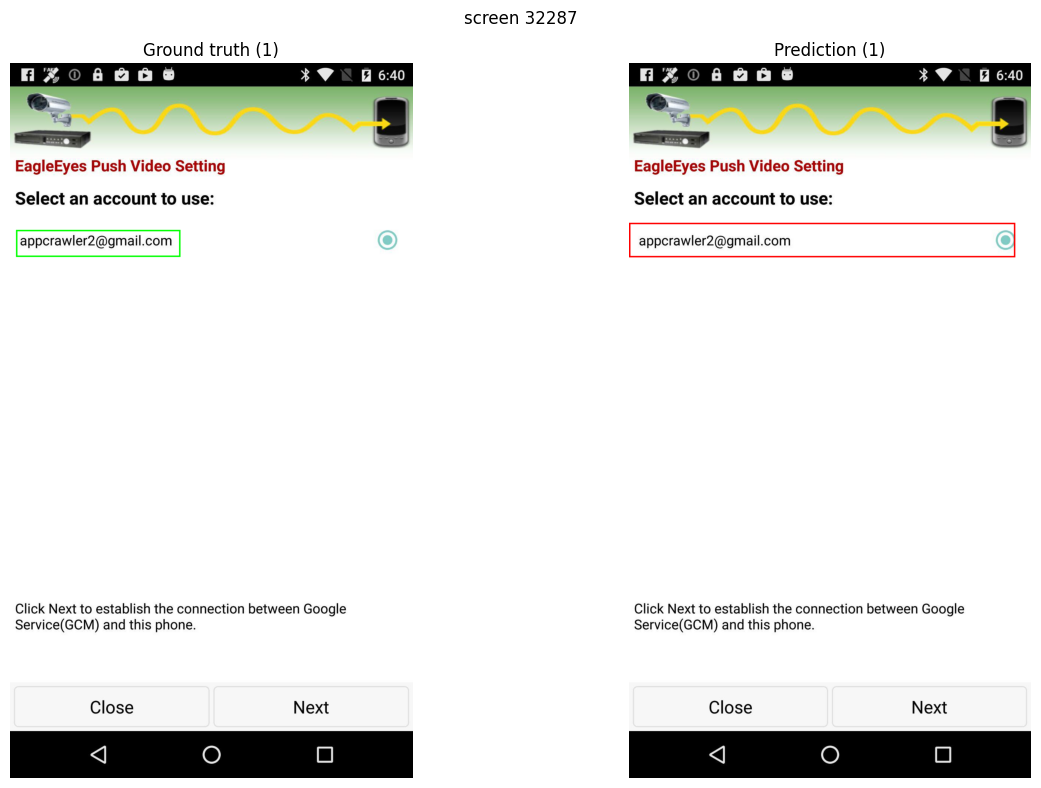

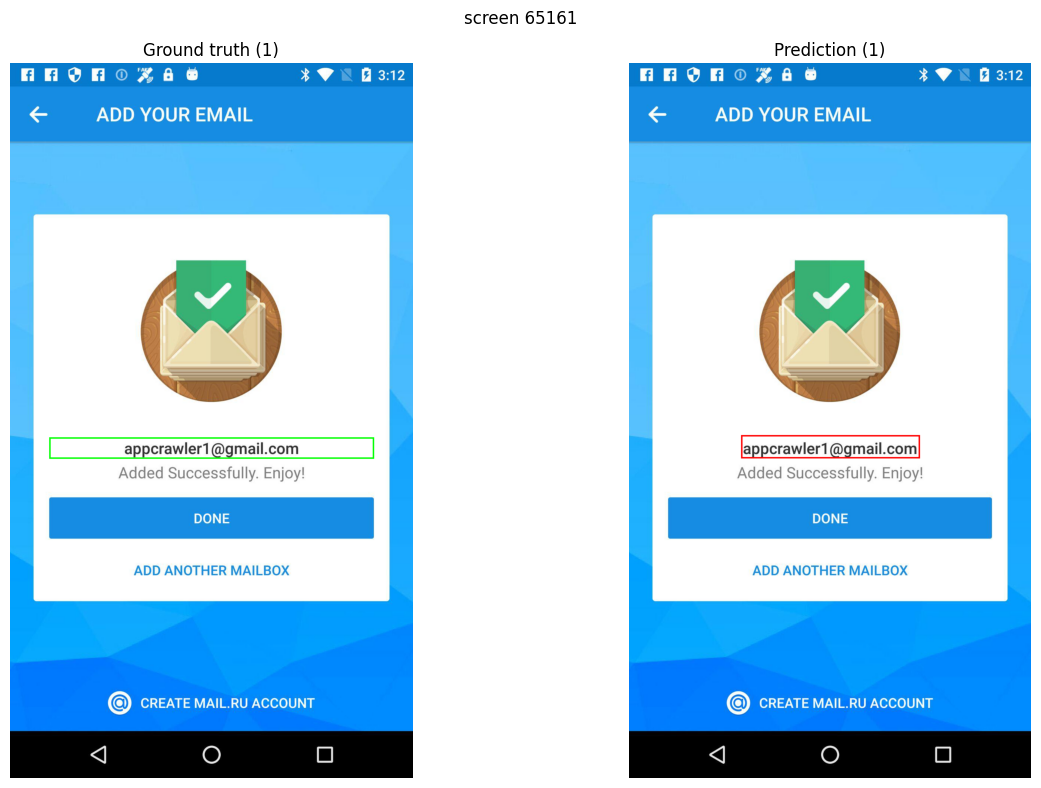

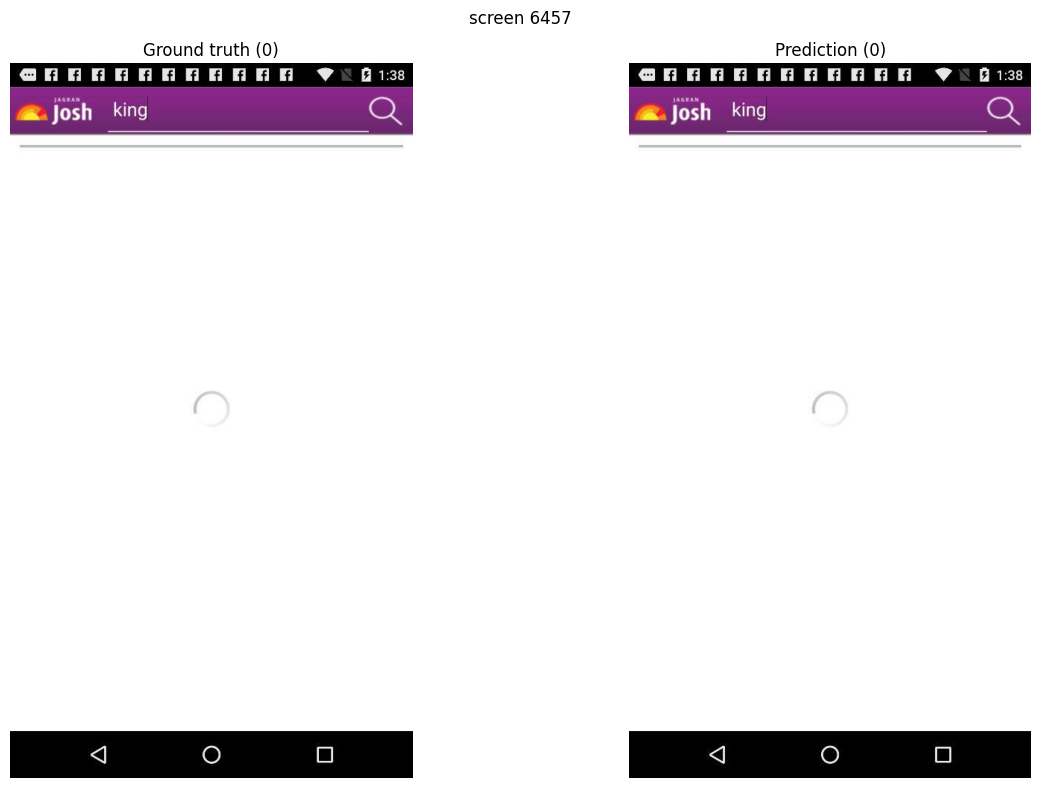

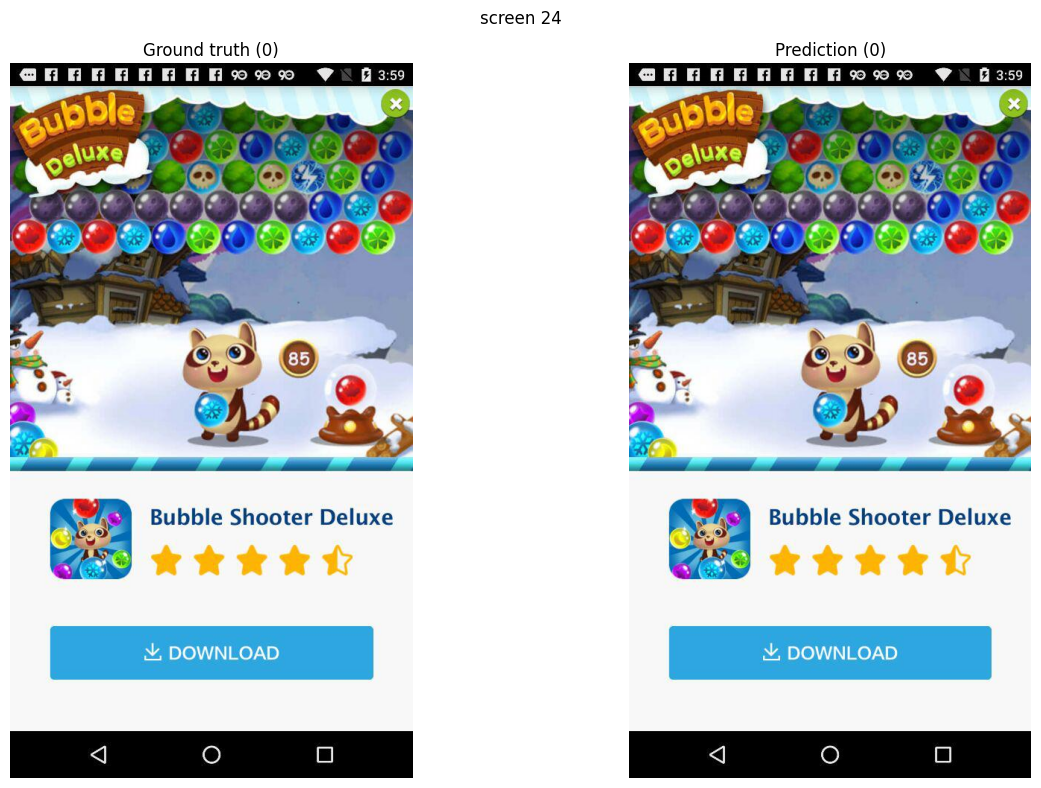

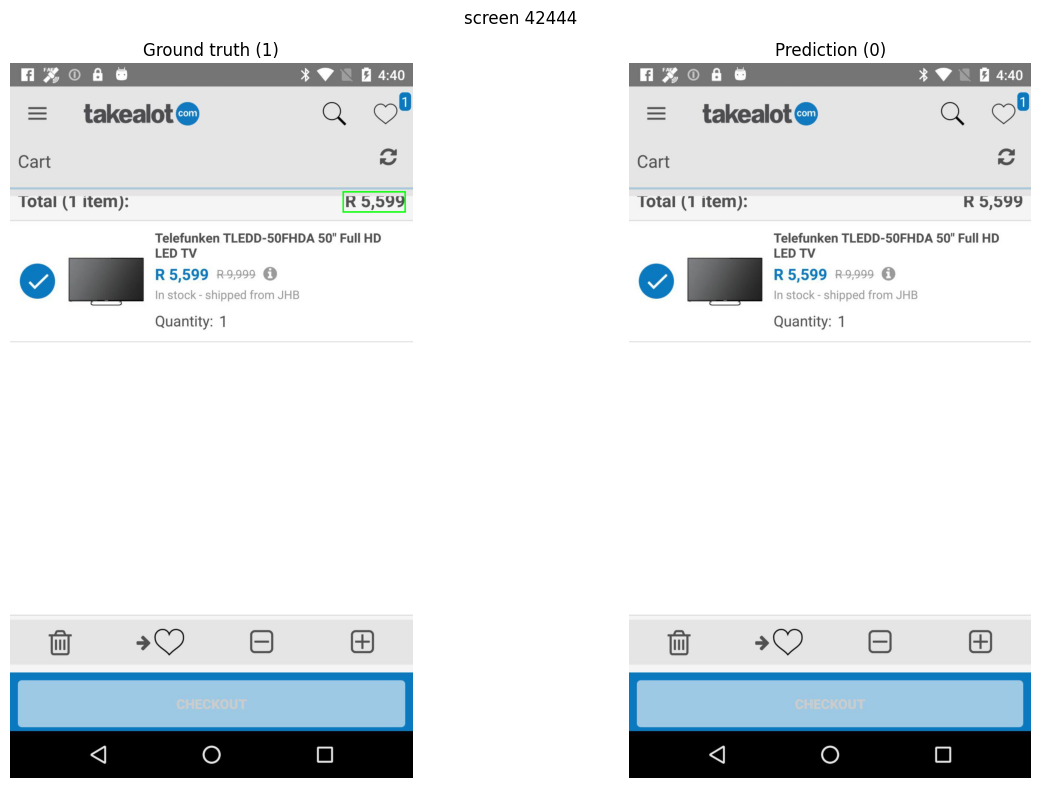

In [33]:
def show(result, idx):
    img = Image.open(DATA_DIR / examples[idx]['image']).convert('RGB')
    fig, ax = plt.subplots(1, 2, figsize=(14, 8))
    for a, title, boxes, color in [
        (ax[0], 'Ground truth', result['gts'],   'lime'),
        (ax[1], 'Prediction',   result['preds'], 'red'),
    ]:
        im = img.copy()
        d = ImageDraw.Draw(im)
        for o in boxes:
            d.rectangle(o['bbox'], outline=color, width=4)
        a.imshow(im); a.set_title(f'{title} ({len(boxes)})'); a.axis('off')
    plt.suptitle(f'screen {result["screen_id"]}')
    plt.tight_layout(); plt.show()

for idx in random.sample(range(len(results)), min(5, len(results))):
    show(results[idx], idx)

## 7. Save eval report (for the final write-up)

In [34]:
report = {
    'split': str(SPLIT_FILE),
    'multi_class': bool(MULTI_CLASS),
    'class_aware_scoring': bool(MULTI_CLASS and CLASS_AWARE_SCORING),
    'prompt': PROMPT,
    'n_examples': len(examples),
    'n_predictions': n_preds,
    'n_ground_truth': n_gts,
    'mean_iou_matched': float(np.mean(all_ious)) if all_ious else 0.0,
    'metrics_at_iou': {},
}
for thr in [0.5, 0.75]:
    tp, fp, fn, p, r, f = prf_at_threshold(all_matches, n_preds, n_gts, thr)
    report['metrics_at_iou'][str(thr)] = dict(tp=tp, fp=fp, fn=fn,
                                              precision=round(p, 4),
                                              recall=round(r, 4),
                                              f1=round(f, 4))
# Honest name: mean precision across IoU sweep (NOT true COCO mAP)
report['mean_precision_across_iou'] = mean_p_across_iou

if MULTI_CLASS:
    report['per_label_at_iou_0.5'] = {
        lbl: {'tp': d['tp'], 'fp': d['fp'], 'fn': d['fn']}
        for lbl, d in per_label.items()
    }

run_tag = 'multiclass' if MULTI_CLASS else 'singleclass'
out = DRIVE_ROOT / 'outputs' / f'eval_report_{DATA_SUBDIR}_{run_tag}.json'
out.parent.mkdir(exist_ok=True, parents=True)
out.write_text(json.dumps(report, indent=2))
print('Saved', out)
print(json.dumps(report, indent=2))

Saved /content/drive/MyDrive/VU_DL_Team_Project/outputs/eval_report_pii_v1_singleclass.json
{
  "split": "/content/scratch/pii_v1/test.jsonl",
  "multi_class": false,
  "class_aware_scoring": false,
  "prompt": "<image>detect sensitive_info",
  "n_examples": 365,
  "n_predictions": 242,
  "n_ground_truth": 414,
  "mean_iou_matched": 0.5490250651268358,
  "metrics_at_iou": {
    "0.5": {
      "tp": 144,
      "fp": 98,
      "fn": 270,
      "precision": 0.595,
      "recall": 0.3478,
      "f1": 0.439
    },
    "0.75": {
      "tp": 99,
      "fp": 143,
      "fn": 315,
      "precision": 0.4091,
      "recall": 0.2391,
      "f1": 0.3018
    }
  },
  "mean_precision_across_iou": 0.3801652892561983
}


In [35]:
from collections import defaultdict
buckets = defaultdict(lambda: {'pred': 0, 'gt': 0, 'tp_05': 0})
for r in results:
    n = len(r['gts'])
    buckets[n]['gt'] += len(r['gts'])
    buckets[n]['pred'] += len(r['preds'])
    buckets[n]['tp_05'] += sum(1 for _, _, iou in r['matches'] if iou >= 0.5)
for n in sorted(buckets):
    b = buckets[n]
    recall = b['tp_05']/b['gt'] if b['gt'] else None
    print(f'screens with {n} GTs: pred={b["pred"]:4d} gt={b["gt"]:4d} '
          f'TP@.5={b["tp_05"]:4d} recall={recall}')

screens with 0 GTs: pred=   8 gt=   0 TP@.5=   0 recall=None
screens with 1 GTs: pred= 184 gt= 240 TP@.5= 115 recall=0.4791666666666667
screens with 2 GTs: pred=  36 gt=  98 TP@.5=  22 recall=0.22448979591836735
screens with 3 GTs: pred=  11 gt=  48 TP@.5=   6 recall=0.125
screens with 4 GTs: pred=   1 gt=   4 TP@.5=   1 recall=0.25
screens with 5 GTs: pred=   1 gt=  10 TP@.5=   0 recall=0.0
screens with 6 GTs: pred=   0 gt=   6 TP@.5=   0 recall=0.0
screens with 8 GTs: pred=   1 gt=   8 TP@.5=   0 recall=0.0


In [36]:
from collections import defaultdict
buckets = defaultdict(lambda: {'pred': 0, 'gt': 0, 'tp_05': 0})
for r in results:
    n = len(r['gts'])
    buckets[n]['gt'] += len(r['gts'])
    buckets[n]['pred'] += len(r['preds'])
    buckets[n]['tp_05'] += sum(1 for _, _, iou in r['matches'] if iou >= 0.5)
for n in sorted(buckets):
    b = buckets[n]
    recall = b['tp_05']/b['gt'] if b['gt'] else None
    print(f'screens with {n} GTs: pred={b["pred"]:4d} gt={b["gt"]:4d} '
          f'TP@.5={b["tp_05"]:4d} recall={recall}')

screens with 0 GTs: pred=   8 gt=   0 TP@.5=   0 recall=None
screens with 1 GTs: pred= 184 gt= 240 TP@.5= 115 recall=0.4791666666666667
screens with 2 GTs: pred=  36 gt=  98 TP@.5=  22 recall=0.22448979591836735
screens with 3 GTs: pred=  11 gt=  48 TP@.5=   6 recall=0.125
screens with 4 GTs: pred=   1 gt=   4 TP@.5=   1 recall=0.25
screens with 5 GTs: pred=   1 gt=  10 TP@.5=   0 recall=0.0
screens with 6 GTs: pred=   0 gt=   6 TP@.5=   0 recall=0.0
screens with 8 GTs: pred=   1 gt=   8 TP@.5=   0 recall=0.0


## What to do with these numbers

**Project success threshold:** the spec says "IoU > 0.5 counts as a successful mask." Track **Recall @ IoU=0.5** — that's how often the model actually caught sensitive content. Anything **≥ 0.70** on the curated PII dataset is a respectable result for a 2-week LoRA fine-tune.

**Honest naming:** the field `mean_precision_across_iou` is **not** COCO mAP — it's just the mean of precision values across IoU thresholds 0.5→0.95. True mAP requires per-image precision-recall curves (see `pycocotools` if you want to add it for the final report).

**If recall is low (<0.4):**
- Train longer (already bumped to 8 epochs + early stopping; can go to 12).
- LoRA rank is already 32 with MLP modules included; try unfreezing more of the language model.
- Run the label-distribution cell in 02_train: if many screens have >12 boxes you're capped by `MAX_OBJECTS`.

**If precision is low but recall is high:**
- Model is over-predicting. Add more empty-objects examples (~20% of train).
- Lower learning rate to 1e-5.

**For the report — recommended comparison table:**

| Setup | Recall@0.5 | Precision@0.5 | F1@0.5 | Mean IoU |
|---|---|---|---|---|
| Regex baseline (M1) | … | … | … | n/a |
| Fine-tuned, single-class (this run) | … | … | … | … |
| Fine-tuned, multi-class (set MULTI_CLASS=True and re-train) | … | … | … | … |
| (Optional) Pretrained PaliGemma zero-shot | … | … | … | … |

That table is the heart of the novelty argument — fine-tuning *and* taxonomy ablation on the same backbone.